In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
%pip install -q opencv-python-headless tqdm pyyaml

In [4]:
from pathlib import Path
import subprocess

REPO_DIR = Path(
    "/content/Low-Light-Image-Enhancement-and-Downstream-Recognition"
)

if not REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth", "1",
            "https://github.com/NMH1203/Low-Light-Image-Enhancement-and-Downstream-Recognition.git",
            str(REPO_DIR),
        ],
        check=True,
    )

SOURCE_DATASET = (
    REPO_DIR
    / "Dataset"
    / "exdark_yolo_dark"
)

OUTPUT_DATASET = Path(
    "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp"
)

assert SOURCE_DATASET.exists(), (
    f"Không tìm thấy dataset nguồn: {SOURCE_DATASET}"
)

print("Dataset nguồn:", SOURCE_DATASET)
print("Dataset kết quả:", OUTPUT_DATASET)

Dataset nguồn: /content/Low-Light-Image-Enhancement-and-Downstream-Recognition/Dataset/exdark_yolo_dark
Dataset kết quả: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp


In [5]:
"""Zero-DCE++ model compatible with the official pretrained checkpoint."""

import cv2
import numpy as np
import torch

from torch import nn
from torch.nn import functional as F


class SeparableConv(nn.Module):
    """Depthwise/pointwise convolution with official checkpoint parameter names."""

    def __init__(
        self,
        input_channels: int,
        output_channels: int,
    ):
        super().__init__()

        self.depth_conv = nn.Conv2d(
            input_channels,
            input_channels,
            3,
            padding=1,
            groups=input_channels,
        )

        self.point_conv = nn.Conv2d(
            input_channels,
            output_channels,
            1,
        )

    def forward(self, image):
        return self.point_conv(
            self.depth_conv(image)
        )


class ZeroDCEPP(nn.Module):
    """Lightweight DCE-Net sharing one RGB curve map across eight iterations."""

    def __init__(self, scale_factor: int = 4):
        super().__init__()

        if scale_factor < 1:
            raise ValueError(
                "Scale factor must be positive."
            )

        self.scale_factor = scale_factor

        self.e_conv1 = SeparableConv(3, 32)
        self.e_conv2 = SeparableConv(32, 32)
        self.e_conv3 = SeparableConv(32, 32)
        self.e_conv4 = SeparableConv(32, 32)
        self.e_conv5 = SeparableConv(64, 32)
        self.e_conv6 = SeparableConv(64, 32)
        self.e_conv7 = SeparableConv(64, 3)

    def forward(self, image):
        features = image

        if self.scale_factor != 1:
            features = F.interpolate(
                image,
                scale_factor=1 / self.scale_factor,
                mode="bilinear",
                align_corners=False,
            )

        first = F.relu(
            self.e_conv1(features)
        )

        second = F.relu(
            self.e_conv2(first)
        )

        third = F.relu(
            self.e_conv3(second)
        )

        fourth = F.relu(
            self.e_conv4(third)
        )

        fifth = F.relu(
            self.e_conv5(
                torch.cat(
                    (third, fourth),
                    dim=1,
                )
            )
        )

        sixth = F.relu(
            self.e_conv6(
                torch.cat(
                    (second, fifth),
                    dim=1,
                )
            )
        )

        curve = torch.tanh(
            self.e_conv7(
                torch.cat(
                    (first, sixth),
                    dim=1,
                )
            )
        )

        if self.scale_factor != 1:
            curve = F.interpolate(
                curve,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=True,
            )

        enhanced = image

        for _ in range(8):
            enhanced = (
                enhanced
                + curve
                * (
                    enhanced.square()
                    - enhanced
                )
            )

        return enhanced


def load_model(
    checkpoint,
    scale_factor=4,
    device="cpu",
):
    """Load a complete official Zero-DCE++ state dictionary."""

    model = ZeroDCEPP(scale_factor)

    state = torch.load(
        checkpoint,
        map_location="cpu",
        weights_only=True,
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    return model.to(device).eval()


def enhance_image(
    image_bgr: np.ndarray,
    model: ZeroDCEPP,
    device="cpu",
) -> np.ndarray:
    """Enhance one BGR image without changing its dimensions."""

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )

    tensor = (
        torch.from_numpy(image_rgb)
        .permute(2, 0, 1)
        .unsqueeze(0)
    )

    tensor = tensor.to(
        device=device,
        dtype=torch.float32,
    ) / 255.0

    with torch.inference_mode():
        result = model(tensor)

    if not torch.isfinite(result).all():
        raise ValueError(
            "The Zero-DCE++ model produced non-finite pixels."
        )

    rgb = (
        result[0]
        .permute(1, 2, 0)
        .clamp(0, 1)
        .mul(255)
        .round()
        .byte()
        .cpu()
        .numpy()
    )

    return cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2BGR,
    )

In [6]:
import hashlib

from pathlib import Path
from urllib.request import urlopen

CHECKPOINT_URL = (
    "https://raw.githubusercontent.com/"
    "Li-Chongyi/Zero-DCE_extension/main/"
    "Zero-DCE%2B%2B/snapshots_Zero_DCE%2B%2B/"
    "Epoch99.pth"
)

EXPECTED_SHA256 = (
    "ca8855b90df9a80fa4195a831f33d3476"
    "b1964f787eb70602797c773067f3b84"
)

CHECKPOINT_PATH = Path(
    "/content/weights/zerodcepp_Epoch99.pth"
)

CHECKPOINT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if not CHECKPOINT_PATH.exists():
    print("Đang tải checkpoint Zero-DCE++...")

    with urlopen(
        CHECKPOINT_URL,
        timeout=120,
    ) as response:
        checkpoint_content = response.read()

    actual_hash = hashlib.sha256(
        checkpoint_content
    ).hexdigest()

    if actual_hash != EXPECTED_SHA256:
        raise ValueError(
            "Checkpoint tải về không đúng SHA-256.\n"
            f"Expected: {EXPECTED_SHA256}\n"
            f"Actual:   {actual_hash}"
        )

    CHECKPOINT_PATH.write_bytes(
        checkpoint_content
    )

actual_hash = hashlib.sha256(
    CHECKPOINT_PATH.read_bytes()
).hexdigest()

if actual_hash != EXPECTED_SHA256:
    raise ValueError(
        "Checkpoint hiện có không hợp lệ."
    )

print("Checkpoint hợp lệ:", CHECKPOINT_PATH)
print("SHA-256:", actual_hash)

Đang tải checkpoint Zero-DCE++...
Checkpoint hợp lệ: /content/weights/zerodcepp_Epoch99.pth
SHA-256: ca8855b90df9a80fa4195a831f33d3476b1964f787eb70602797c773067f3b84


In [7]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

SCALE_FACTOR = 4

model = load_model(
    checkpoint=CHECKPOINT_PATH,
    scale_factor=SCALE_FACTOR,
    device=DEVICE,
)

print("Device:", DEVICE)
print("Scale factor:", SCALE_FACTOR)
print("Model:", type(model).__name__)

Device: cuda
Scale factor: 4
Model: ZeroDCEPP


In [8]:
import os
import shutil

from tqdm.auto import tqdm

SPLITS = [
    "train",
    "valid",
    "test",
]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}

processed_count = 0
skipped_count = 0

for split in SPLITS:
    source_images_dir = (
        SOURCE_DATASET
        / split
        / "images"
    )

    source_labels_dir = (
        SOURCE_DATASET
        / split
        / "labels"
    )

    output_images_dir = (
        OUTPUT_DATASET
        / split
        / "images"
    )

    output_labels_dir = (
        OUTPUT_DATASET
        / split
        / "labels"
    )

    output_images_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_labels_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    image_paths = sorted(
        path
        for path in source_images_dir.iterdir()
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )

    label_paths = sorted(
        source_labels_dir.glob("*.txt")
    )

    print(
        f"\n{split}: "
        f"{len(image_paths)} ảnh, "
        f"{len(label_paths)} labels"
    )

    if len(image_paths) != len(label_paths):
        raise ValueError(
            f"Số ảnh và labels không bằng nhau "
            f"trong split {split}"
        )

    # Sao chép nguyên nhãn YOLO.
    # Zero-DCE++ không resize, crop hay biến đổi hình học.
    for label_path in label_paths:
        destination_label = (
            output_labels_dir
            / label_path.name
        )

        shutil.copy2(
            label_path,
            destination_label,
        )

    # Xử lý tuần tự, không dùng workers.
    for image_path in tqdm(
        image_paths,
        desc=f"Zero-DCE++ {split}",
    ):
        output_path = (
            output_images_dir
            / f"{image_path.stem}.png"
        )

        # Cho phép tiếp tục nếu Colab bị ngắt.
        if (
            output_path.exists()
            and output_path.stat().st_size > 0
        ):
            skipped_count += 1
            continue

        image_bgr = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR,
        )

        if (
            image_bgr is None
            or image_bgr.size == 0
        ):
            raise ValueError(
                f"Không đọc được ảnh: {image_path}"
            )

        original_shape = image_bgr.shape

        enhanced_bgr = enhance_image(
            image_bgr=image_bgr,
            model=model,
            device=DEVICE,
        )

        if enhanced_bgr.shape != original_shape:
            raise ValueError(
                "Zero-DCE++ đã làm thay đổi "
                f"kích thước ảnh: {image_path}"
            )

        # Ghi vào file tạm trước để tránh file hỏng
        # khi Colab bị ngắt giữa chừng.
        temporary_path = output_path.with_name(
            output_path.stem
            + ".temporary.png"
        )

        success = cv2.imwrite(
            str(temporary_path),
            enhanced_bgr,
            [cv2.IMWRITE_PNG_COMPRESSION, 3],
        )

        if not success:
            raise IOError(
                f"Không lưu được ảnh: {output_path}"
            )

        os.replace(
            temporary_path,
            output_path,
        )

        processed_count += 1

print("\nHoàn thành Zero-DCE++")
print("Ảnh mới xử lý:", processed_count)
print("Ảnh đã tồn tại:", skipped_count)


train: 5142 ảnh, 5142 labels


Zero-DCE++ train:   0%|          | 0/5142 [00:00<?, ?it/s]


valid: 1469 ảnh, 1469 labels


Zero-DCE++ valid:   0%|          | 0/1469 [00:00<?, ?it/s]


test: 734 ảnh, 734 labels


Zero-DCE++ test:   0%|          | 0/734 [00:00<?, ?it/s]


Hoàn thành Zero-DCE++
Ảnh mới xử lý: 7345
Ảnh đã tồn tại: 0


In [9]:
import yaml

source_yaml_path = (
    SOURCE_DATASET
    / "data.yaml"
)

output_yaml_path = (
    OUTPUT_DATASET
    / "data.yaml"
)

with open(
    source_yaml_path,
    "r",
    encoding="utf-8",
) as file:
    dataset_config = yaml.safe_load(file)

dataset_config["path"] = (
    OUTPUT_DATASET.as_posix()
)

dataset_config["train"] = (
    "train/images"
)

dataset_config["val"] = (
    "valid/images"
)

dataset_config["test"] = (
    "test/images"
)

if "names" in dataset_config:
    dataset_config["nc"] = len(
        dataset_config["names"]
    )

with open(
    output_yaml_path,
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        dataset_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Đã tạo:", output_yaml_path)
print()
print(
    output_yaml_path.read_text(
        encoding="utf-8"
    )
)

Đã tạo: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp/data.yaml

path: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp
train: train/images
val: valid/images
test: test/images
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Cat
  5: Cup
  6: Motorbike
  7: People
  8: Table
  9: car
  10: chair
  11: dog
nc: 12



In [10]:
import json
import hashlib

from datetime import datetime, timezone

metadata = {
    "created_at_utc": (
        datetime.now(timezone.utc).isoformat()
    ),
    "method": "Zero-DCE++",
    "implementation": "HienAnh",
    "model": "ZeroDCEPP",
    "scale_factor": SCALE_FACTOR,
    "device": DEVICE,
    "checkpoint": CHECKPOINT_PATH.name,
    "checkpoint_sha256": hashlib.sha256(
        CHECKPOINT_PATH.read_bytes()
    ).hexdigest(),
    "checkpoint_source": CHECKPOINT_URL,
    "image_format": "PNG",
    "geometry": (
        "Original dimensions; "
        "no resize, crop or augmentation"
    ),
    "source_dataset": str(SOURCE_DATASET),
    "output_dataset": str(OUTPUT_DATASET),
}

metadata_path = (
    OUTPUT_DATASET
    / "enhancement.json"
)

metadata_path.write_text(
    json.dumps(
        metadata,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Đã tạo:", metadata_path)

Đã tạo: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp/enhancement.json


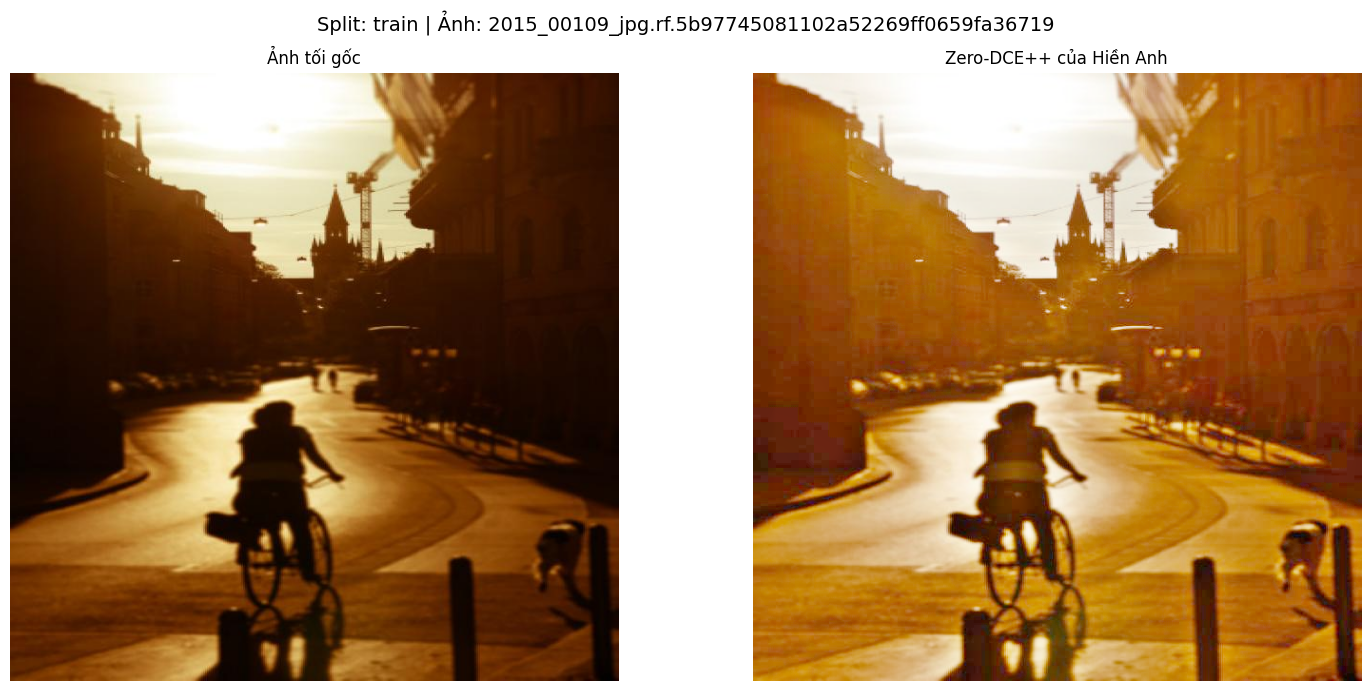

Ảnh gốc: /content/Low-Light-Image-Enhancement-and-Downstream-Recognition/Dataset/exdark_yolo_dark/train/images/2015_00109_jpg.rf.5b97745081102a52269ff0659fa36719.jpg
Ảnh Zero-DCE++: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp/train/images/2015_00109_jpg.rf.5b97745081102a52269ff0659fa36719.png


In [11]:
import random
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

DARK_DATASET = (
    REPO_DIR
    / "Dataset"
    / "exdark_yolo_dark"
)

ZERODCE_DATASET = Path(
    "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_zerodcepp"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp", ".tif", ".tiff",
}

# Chọn ngẫu nhiên một split
split = random.choice([
    "train",
    "valid",
    "test",
])

zerodce_image_dir = (
    ZERODCE_DATASET
    / split
    / "images"
)

zerodce_images = [
    path
    for path in zerodce_image_dir.iterdir()
    if (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not zerodce_images:
    raise FileNotFoundError(
        f"Không tìm thấy ảnh Zero-DCE++ trong {zerodce_image_dir}"
    )

# Chọn ngẫu nhiên một ảnh Zero-DCE++
zerodce_path = random.choice(zerodce_images)

# Tìm ảnh tối gốc có cùng tên stem
dark_image_dir = (
    DARK_DATASET
    / split
    / "images"
)

dark_candidates = [
    path
    for path in dark_image_dir.iterdir()
    if (
        path.is_file()
        and path.stem == zerodce_path.stem
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not dark_candidates:
    raise FileNotFoundError(
        f"Không tìm được ảnh gốc của {zerodce_path.name}"
    )

dark_path = dark_candidates[0]

# Đọc ảnh
dark_bgr = cv2.imread(
    str(dark_path),
    cv2.IMREAD_COLOR,
)

zerodce_bgr = cv2.imread(
    str(zerodce_path),
    cv2.IMREAD_COLOR,
)

if dark_bgr is None:
    raise ValueError(
        f"Không đọc được ảnh gốc: {dark_path}"
    )

if zerodce_bgr is None:
    raise ValueError(
        f"Không đọc được ảnh Zero-DCE++: {zerodce_path}"
    )

# OpenCV dùng BGR, matplotlib dùng RGB
dark_rgb = cv2.cvtColor(
    dark_bgr,
    cv2.COLOR_BGR2RGB,
)

zerodce_rgb = cv2.cvtColor(
    zerodce_bgr,
    cv2.COLOR_BGR2RGB,
)

# Hiển thị hai ảnh
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(dark_rgb)
plt.title("Ảnh tối gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(zerodce_rgb)
plt.title("Zero-DCE++ của Hiền Anh")
plt.axis("off")

plt.suptitle(
    f"Split: {split} | Ảnh: {zerodce_path.stem}",
    fontsize=14,
)

plt.tight_layout()
plt.show()

print("Ảnh gốc:", dark_path)
print("Ảnh Zero-DCE++:", zerodce_path)